# Task 4
## Classification Models, Evaluation Metrics & Handling Imbalanced Data

# 1. AIM

To develop and evaluate a binary classification model using the Breast Cancer Wisconsin Dataset. The objective is to train and compare Logistic Regression and Decision Tree classifiers, evaluate their performance using Confusion Matrix, Precision, Recall, F1-Score, ROC Curve, and AUC Score, and study the impact of handling class imbalance using class weighting techniques.

# 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# 3. Load Dataset

In [15]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target 

# 4. Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Logistic Regression Model

In [18]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Predictions Completed")

Predictions Completed


# 7. Confusion Matrix & Classification Report

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

balanced_model.fit(X_train_scaled, y_train)

balanced_pred = balanced_model.predict(X_test_scaled)

print(classification_report(y_test, balanced_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



# 8. Precision, Recall and F1 Score

### Precision
Precision measures how many predicted positive cases are actually positive.

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Where:

- **TP** = True Positives
- **FP** = False Positives

### Recall
Recall measures how many actual positive cases are correctly identified.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Where:

- **TP** = True Positives
- **FN** = False Negatives

### F1 Score
F1 Score is the harmonic mean of Precision and Recall. It provides a balance between the two metrics.

$$
\text{F1 Score} =
2 \times
\frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

### Medical Diagnosis
In medical diagnosis, **Recall** is often more important because failing to identify a patient with cancer (**False Negative**) can have serious consequences. A higher recall ensures that most actual cancer cases are detected.

### Why Accuracy Alone Is Misleading
Accuracy may not always reflect the true performance of a model, especially when dealing with imbalanced datasets. A model can achieve high accuracy by correctly predicting the majority class while failing to identify important minority class instances.

### Why F1 Score is Preferred
The **F1 Score** combines both Precision and Recall into a single metric, making it particularly useful for evaluating models on imbalanced datasets where both false positives and false negatives are important.

# 9. ROC Curve & AUC Score
### AUC Score

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.9953703703703703


###  ROC Curve 

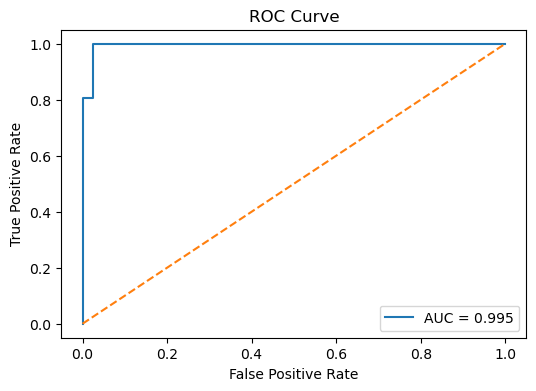

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

# 10. Handle Class Imbalance

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

balanced_model.fit(X_train_scaled, y_train)

balanced_pred = balanced_model.predict(X_test_scaled)

print(classification_report(y_test, balanced_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



# 11. Compare With Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [31]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

